## **K-Means from Scratch**

### **Topic Roadmap**

**1. Load the original student dataset**

**2. Initialize centroids**

**3. Assign points and update centroids**

**4. Repeat until convergence**

**5. Compare with scikit-learn**

**6. Key revision notes**

## **1. Dataset**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans

RANDOM_STATE = 42
students = pd.read_csv("docs/Lecture-096-student_clustering.csv")
X = students[["cgpa", "iq"]].to_numpy(dtype=float)

## **2. Implement the Algorithm**

Each iteration has two steps: assign each point to its nearest centroid, then replace each centroid with the mean of its assigned points.

In [4]:
class KMeansScratch:
    def __init__(self, n_clusters=4, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        self.cluster_centers_ = X[rng.choice(len(X), self.n_clusters, replace=False)].copy()
        for iteration in range(self.max_iter):
            distances = np.linalg.norm(X[:, None, :] - self.cluster_centers_[None, :, :], axis=2)
            labels = distances.argmin(axis=1)
            new_centers = np.vstack([
                X[labels == cluster].mean(axis=0) if np.any(labels == cluster) else self.cluster_centers_[cluster]
                for cluster in range(self.n_clusters)
            ])
            shift = np.linalg.norm(new_centers - self.cluster_centers_)
            self.cluster_centers_ = new_centers
            if shift <= self.tol:
                break
        self.labels_ = labels
        self.n_iter_ = iteration + 1
        self.inertia_ = np.sum((X - self.cluster_centers_[labels]) ** 2)
        return self

    def predict(self, X):
        distances = np.linalg.norm(X[:, None, :] - self.cluster_centers_[None, :, :], axis=2)
        return distances.argmin(axis=1)

In [5]:
scratch = KMeansScratch(random_state=RANDOM_STATE).fit(X)
print("Iterations:", scratch.n_iter_)
print("Inertia:", scratch.inertia_)

Iterations: 3
Inertia: 681.96966


## **3. Visualize and Compare**

Cluster identifiers can be permuted, so compare centroids and inertia rather than requiring identical label numbers.

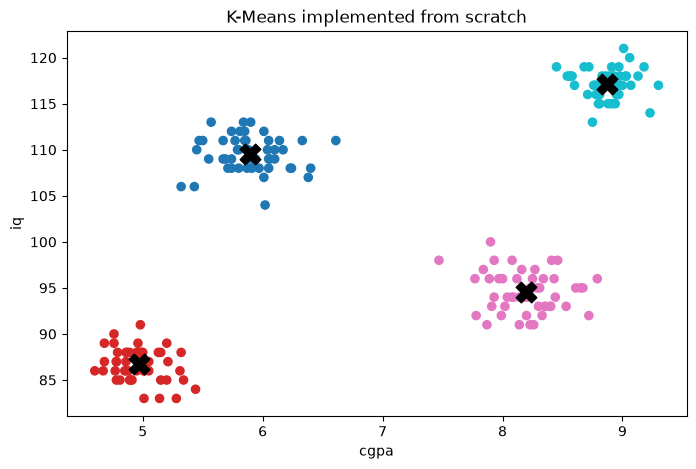

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=scratch.labels_, cmap="tab10", s=35)
plt.scatter(scratch.cluster_centers_[:, 0], scratch.cluster_centers_[:, 1], c="black", marker="X", s=220)
plt.xlabel("cgpa")
plt.ylabel("iq")
plt.title("K-Means implemented from scratch")
plt.show()

In [7]:
sklearn_model = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X)
print(f"Scratch inertia: {scratch.inertia_:.2f}")
print(f"scikit-learn inertia: {sklearn_model.inertia_:.2f}")

Scratch inertia: 681.97
scikit-learn inertia: 681.97


### **Key Revision Notes**

- Assignment uses nearest-centroid Euclidean distance.
- The update step uses the mean of each cluster.
- Empty clusters need an explicit fallback or reinitialization policy.
- Initialization affects the local optimum; `n_init` reduces this sensitivity in scikit-learn.